In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# Set dataset paths
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/cataract_dataset/augmented"  # Change this to your dataset path
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")

# Ensure paths exist
if os.path.exists(BASE_DIR):
    print("✅ Dataset directory found!")
else:
    print("❌ Dataset directory NOT found. Check your path.")
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import random
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
import shutil
from sklearn.model_selection import train_test_split

# Define paths
base_path = "/content/drive/My Drive/Colab Notebooks/cataract_dataset"
train_path = os.path.join(base_path, "train")
test_path = os.path.join(base_path, "test")

# Function to count images in a folder
def count_images(folder_path):
    count = {}
    for category in os.listdir(folder_path):
        category_path = os.path.join(folder_path, category)
        if os.path.isdir(category_path):
            count[category] = len(os.listdir(category_path))
    return count

# Get image counts
train_counts = count_images(train_path)
test_counts = count_images(test_path)

# Print results
print("Train set image counts:", train_counts)
print("Test set image counts:", test_counts)




Mounted at /content/drive
✅ Dataset directory found!
Train set image counts: {'cataract': 3760, 'normal': 3779}
Test set image counts: {'cataract': 940, 'normal': 945}


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# Define paths
base_dir = "/content/drive/My Drive/Colab Notebooks/cataract_dataset"
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

# Image dimensions
IMG_HEIGHT, IMG_WIDTH = 224, 224  # ResNet expects 224x224 images
BATCH_SIZE = 32

# Data augmentation and normalization
train_datagen = ImageDataGenerator(rescale=1.0/255)
test_datagen = ImageDataGenerator(rescale=1.0/255)


# Load images from directories
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)
print("Class indices:", train_generator.class_indices)
print("Training samples per class:", train_generator.classes)
print("Total training images:", train_generator.samples)

print("Testing samples per class:", test_generator.classes)
print("Total testing images:", test_generator.samples)



Found 7539 images belonging to 2 classes.
Found 1885 images belonging to 2 classes.
Class indices: {'cataract': 0, 'normal': 1}
Training samples per class: [0 0 0 ... 1 1 1]
Total training images: 7539
Testing samples per class: [0 0 0 ... 1 1 1]
Total testing images: 1885


display sample

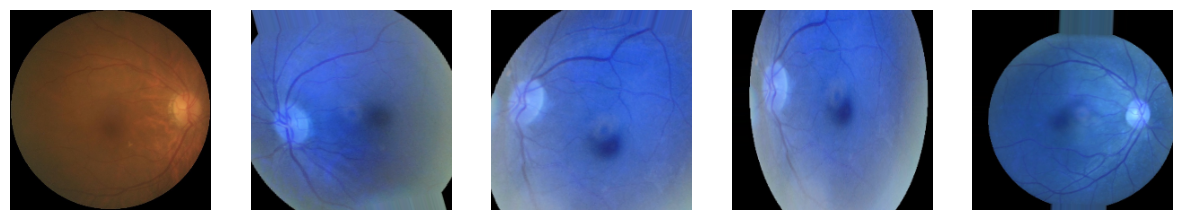

In [ ]:
import os
import cv2
import numpy as np
import hashlib
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
#✅ Display some sample images before and after resizing
OUTPUT_FOLDER = "/content/drive/My Drive/Colab Notebooks/cataract_dataset/train/normal"
def display_sample_images():
    sample_images = [os.path.join(OUTPUT_FOLDER, f) for f in os.listdir(OUTPUT_FOLDER) if f.endswith(('.png', '.jpg', '.jpeg'))][:5]

    fig, axs = plt.subplots(1, len(sample_images), figsize=(15, 5))
    for i, img_path in enumerate(sample_images):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axs[i].imshow(img)
        axs[i].axis("off")
    plt.show()

# ✅ Show images
display_sample_images()

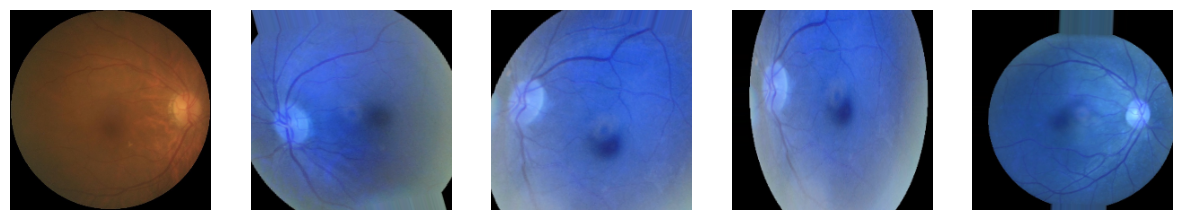

In [ ]:
import os
import cv2
import numpy as np
import hashlib
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
#✅ Display some sample images before and after resizing
OUTPUT_FOLDER = "/content/drive/My Drive/Colab Notebooks/cataract_dataset/train/cataract"
def display_sample_images():
    sample_images = [os.path.join(OUTPUT_FOLDER, f) for f in os.listdir(OUTPUT_FOLDER) if f.endswith(('.png', '.jpg', '.jpeg'))][:5]

    fig, axs = plt.subplots(1, len(sample_images), figsize=(15, 5))
    for i, img_path in enumerate(sample_images):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axs[i].imshow(img)
        axs[i].axis("off")
    plt.show()

# ✅ Show images
display_sample_images()

In [ ]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input

# Load Pre-trained VGG16 model (without the classification head)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Define dataset path
dataset_path = "/content/drive/MyDrive/Colab Notebooks/cataract_dataset/train"

# Function to extract features
def extract_features(directory):
    data = []
    labels = []

    for category in os.listdir(directory):  # Cataract, Normal
        category_path = os.path.join(directory, category)
        if os.path.isdir(category_path):
            for img_name in os.listdir(category_path):
                img_path = os.path.join(category_path, img_name)

                # Load image and preprocess
                img = load_img(img_path, target_size=(224, 224))
                img_array = img_to_array(img)
                img_array = np.expand_dims(img_array, axis=0)
                img_array = preprocess_input(img_array)  # Normalize for VGG16

                # Extract features
                features = base_model.predict(img_array)
                features = features.flatten()  # Flatten the feature map

                # Append to data
                data.append(features)
                labels.append(1 if category.lower() == "cataract" else 0)  # Convert to binary (Cataract=1, Normal=0)
  # Label (Cataract or Normal)

    return np.array(data), np.array(labels)

# Extract features from dataset
X, y = extract_features(dataset_path)
print(f"Feature shape for {img_name}: {features.shape}")

# Convert to DataFrame
df = pd.DataFrame(X)
df['label'] = y  # Add labels

# Save as CSV
csv_path = "/content/drive/MyDrive/Colab Notebooks/cataract_features.csv"
df.to_csv(csv_path, index=False)

print(f"✅ CSV saved at: {csv_path}")
print(df.head())  # Print sample rows
print("Unique train labels:", np.unique(y))  # Check train labels


Streaming output truncated to the last 5000 lines.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 522ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 514ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 511ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 666ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 926ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 883ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 500ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 505ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 509ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 509ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 517ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 501ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 518ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 513ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 932ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 887ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 837ms/step
1/1 ━━━━━━━━━

In [ ]:
import pandas as pd

# Load the extracted features
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/cataract_features.csv')

# Check the first few rows
print(df.head())
print(df['label'].value_counts())


     0    1    2    3    4    5    6    7    8    9  ...      25079  25080  \
0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   0.000000    0.0   
1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   0.000000    0.0   
2  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  17.187828    0.0   
3  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   0.000000    0.0   
4  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  11.345804    0.0   

   25081  25082  25083  25084  25085      25086  25087     label  
0    0.0    0.0    0.0    0.0    0.0  12.970346    0.0  cataract  
1    0.0    0.0    0.0    0.0    0.0   6.631899    0.0  cataract  
2    0.0    0.0    0.0    0.0    0.0  16.174696    0.0  cataract  
3    0.0    0.0    0.0    0.0    0.0   7.146629    0.0  cataract  
4    0.0    0.0    0.0    0.0    0.0   8.475592    0.0  cataract  

[5 rows x 25089 columns]
label
normal      3779
cataract    3760
Name: count, dtype: int64


In [ ]:
import pandas as pd

# Load the extracted feature dataset
csv_path = "/content/drive/MyDrive/Colab Notebooks/cataract_features.csv"  # Change if needed
df = pd.read_csv(csv_path)

# Check unique labels
unique_labels = df['label'].unique()

# Print results
print(f"✅ Unique labels in dataset: {unique_labels}")

# Count occurrences of each category
label_counts = df['label'].value_counts()
print("\n📊 Label distribution:")
print(label_counts)


✅ Unique labels in dataset: ['cataract' 'normal']

📊 Label distribution:
label
normal      3779
cataract    3760
Name: count, dtype: int64


In [ ]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input

# ✅ Load the training dataset CSV into df_train
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/cataract_features.csv")  # Update path if needed

# ✅ Load the testing dataset CSV into df_test (you'll likely need it later)
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/cataract_test_features.csv")  # Update path if needed
df_train['label'] = df_train['label'].map({'cataract': 1, 'normal': 0})
df_test['label'] = df_test['label'].map({'cataract': 1, 'normal': 0})
print("✅ Unique values in y_train:", df_train['label'].unique())
print("✅ Unique values in y_test:", df_test['label'].unique())


✅ Unique values in y_train: [1 0]
✅ Unique values in y_test: [1 0]


In [ ]:
#test data feature exctract and csv verion


In [ ]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input

# Load Pre-trained VGG16 model (without the classification head)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Define dataset path
dataset_path = "/content/drive/MyDrive/Colab Notebooks/cataract_dataset/test"

# Function to extract features
def extract_features(directory):
    data = []
    labels = []

    for category in os.listdir(directory):  # Cataract, Normal
        category_path = os.path.join(directory, category)
        if os.path.isdir(category_path):
            for img_name in os.listdir(category_path):
                img_path = os.path.join(category_path, img_name)

                # Load image and preprocess
                img = load_img(img_path, target_size=(224, 224))
                img_array = img_to_array(img)
                img_array = np.expand_dims(img_array, axis=0)
                img_array = preprocess_input(img_array)  # Normalize for VGG16

                # Extract features
                features = base_model.predict(img_array)
                features = features.flatten()  # Flatten the feature map

                # Append to data
                data.append(features)
                labels.append(category)  # Label (Cataract or Normal)

    return np.array(data), np.array(labels)

# Extract features from dataset
X, y = extract_features(dataset_path)

# Convert to DataFrame
df = pd.DataFrame(X)
df['label'] = y  # Add labels

# Save as CSV
csv_path = "/content/drive/MyDrive/Colab Notebooks/cataract_test_features.csv"
df.to_csv(csv_path, index=False)

print(f"✅ CSV saved at: {csv_path}")
print(df.head())  # Print sample rows


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 929ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 876ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 581ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 575ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 560ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 515ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 847ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 908ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 582ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 511ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 517ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 511ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 679ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 520ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 502ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 513ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 573ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 915

In [ ]:
import pandas as pd

# Load test feature dataset
df_test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/cataract_test_features.csv')

# Check unique labels
unique_labels = df_test['label'].unique()
print(f"✅ Unique labels in test dataset: {unique_labels}")

# Check label distribution
label_counts = df_test['label'].value_counts()
print("\n📊 Label distribution in test set:")
print(label_counts)
print("✅ Unique values in y_train:", df_train['label'].unique())
print("✅ Unique values in y_test:", df_test['label'].unique())


✅ Unique labels in test dataset: ['cataract' 'normal']

📊 Label distribution in test set:
label
normal      945
cataract    940
Name: count, dtype: int64
✅ Unique values in y_train: [1 0]
✅ Unique values in y_test: ['cataract' 'normal']


In [ ]:
import pandas as pd

# Load the extracted feature dataset
csv_path = "/content/drive/MyDrive/Colab Notebooks/cataract_test_features.csv"  # Change if needed
df = pd.read_csv(csv_path)

# Check unique labels
unique_labels = df['label'].unique()

# Print results
print(f"✅ Unique labels in dataset: {unique_labels}")

# Count occurrences of each category
label_counts = df['label'].value_counts()
print("\n📊 Label distribution:")
print(label_counts)


✅ Unique labels in dataset: ['cataract' 'normal']

📊 Label distribution:
label
normal      945
cataract    940
Name: count, dtype: int64


Testing

In [ ]:
import cv2
import numpy as np
import pandas as pd
import joblib
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as preprocess_vgg
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten

# ---- Load Trained Random Forest Model ----
model_path = "/content/drive/MyDrive/rf_cataract_model.pkl"  # Update path
rf_model = joblib.load(model_path)

# ---- Load VGG16 Feature Extractor (With Flatten Layer) ----
base_model = VGG16(weights="imagenet", include_top=False)
flatten_layer = Flatten()(base_model.output)  # Flatten the extracted features
vgg = Model(inputs=base_model.input, outputs=flatten_layer)  # New model with flatten output

# ---- Function to Process Image and Extract Features ----
def extract_features(image_path):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (224, 224))  # Resize to model input size
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
    img = np.expand_dims(img, axis=0)  # Add batch dimension
    img = preprocess_vgg(img)  # Preprocess for VGG16

    features = vgg.predict(img)  # Extract features
    return features  # Now returns flattened 25,088 features

# ---- Input Image Path ----
image_path = "/content/drive/MyDrive/Colab Notebooks/cataract_dataset/test/normal/2349_right_0_6132.png"
features = extract_features(image_path)

# ---- Convert to DataFrame (Match CSV Format) ----
features_df = pd.DataFrame(features)

# ---- Make Prediction ----
prediction = rf_model.predict(features_df)[0]

# ---- Print Result ----
if prediction == 1:
    print("Prediction: Cataract Detected")
else:
    print("Prediction: Normal Eye")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: Normal Eye


Evaluation


In [ ]:
# Load test features from CSV
import pandas
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/cataract_test_features.csv")
clf = joblib.load("/content/drive/MyDrive/rf_cataract_model.pkl")  # Change filename if needed
# Split features and labels
df_test['label'] = df_test['label'].map({'cataract': 1, 'normal': 0})
X_test = df_test.iloc[:, :-1].values
y_test = df_test.iloc[:, -1].values
import joblib

# Predict test set
y_pred = clf.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 Test Accuracy: {accuracy * 100:.2f}%")

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Normal", "Cataract"]))

print("\n🔹 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


🎯 Test Accuracy: 94.48%

📊 Classification Report:
              precision    recall  f1-score   support

      Normal       0.95      0.94      0.94       945
    Cataract       0.94      0.95      0.94       940

    accuracy                           0.94      1885
   macro avg       0.94      0.94      0.94      1885
weighted avg       0.94      0.94      0.94      1885


🔹 Confusion Matrix:
[[892  53]
 [ 51 889]]


confusion matrix


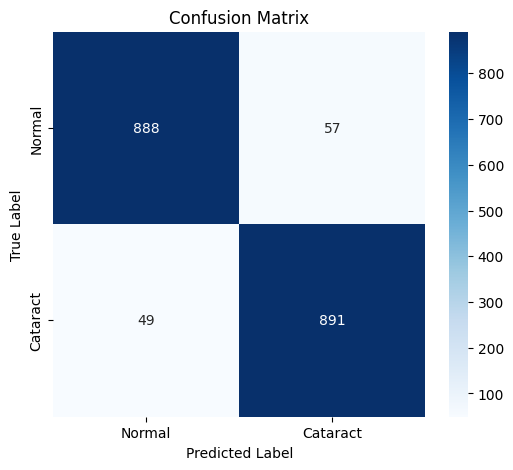

✅ Confusion matrix saved as 'confusion_matrix.png'


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Define class labels
class_labels = ["Normal", "Cataract"]

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

# Save the confusion matrix as an image
plt.savefig("confusion_matrix.png")  # Saves to current directory
plt.show()

print("✅ Confusion matrix saved as 'confusion_matrix.png'")


In [ ]:
import pandas as pd

# Load labels from your dataset file
train_data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/cataract_features.csv")
test_data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/cataract_test_features.csv")

# Extract labels
y_train = train_data['label'].values
y_test = test_data['label'].values


frontend using GRADIO interface

In [ ]:
!pip install gradio
import gradio as gr
import cv2
import numpy as np
import pandas as pd
import joblib
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model

# Load Trained Random Forest Model
model_path = "/content/drive/MyDrive/rf_cataract_model.pkl"  # Update path
rf_model = joblib.load(model_path)

# Load VGG16 Model for Feature Extraction
vgg = VGG16(weights="imagenet", include_top=False, pooling="avg")

# Function to Process Image and Extract Features
def extract_features(image):
    img = cv2.resize(image, (224, 224))  # Resize to VGG16 input size
    img = np.expand_dims(img, axis=0)  # Add batch dimension
    img = preprocess_input(img)  # Apply VGG16 preprocessing
    features = vgg.predict(img)  # Extract features
    return features

# Function for Prediction
def predict_cataract(image):
    image = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)  # Convert PIL image to OpenCV
    features = extract_features(image)
    features_df = pd.DataFrame(features)  # Convert to DataFrame
    prediction = rf_model.predict(features_df)[0]  # Make prediction
    return "Cataract Detected" if prediction == 1 else "Normal Eye"

# Gradio Interface
interface = gr.Interface(
    fn=predict_cataract,
    inputs=gr.Image(type="pil"),
    outputs="text",
    title="Cataract Detection with VGG16 & Random Forest",
    description="Upload an eye image to detect cataract using a VGG16 feature extractor and Random Forest classifier."
)

# Launch App
interface.launch()


Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://63caedee672c9a2a76.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
!pip install gradio
!pip install lime
import numpy as np
import gradio as gr
import joblib  # Updated to joblib for model loading
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model
import cv2
import os
import tensorflow as tf
from lime import lime_image
from skimage.segmentation import mark_boundaries

# Define model path (update with your correct Drive path)
MODEL_PATH = "/content/drive/MyDrive/rf_cataract_model.pkl"

# Function to load model using joblib
def load_model(path):
    try:
        if os.path.exists(path):
            model = joblib.load(path)
            print("✅ RF Model Loaded Successfully")
            return model
        else:
            print("❌ Model file not found")
            return None
    except Exception as e:
        print("❌ Error Loading RF Model:", e)
        return None

rf_model = load_model(MODEL_PATH)

# Load VGG16 model for feature extraction and Grad-CAM
vgg_model = VGG16(weights='imagenet', include_top=False)
last_conv_layer = vgg_model.get_layer("block5_conv3")
grad_model = Model(inputs=vgg_model.input, outputs=[last_conv_layer.output, vgg_model.output])

def preprocess_image(img):
    try:
        if len(img.shape) == 2 or img.shape[-1] != 3:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        img = cv2.resize(img, (224, 224))
        img = np.expand_dims(img, axis=0)
        img = preprocess_input(img)
        print("✅ Image Preprocessed, Shape:", img.shape)
        return img
    except Exception as e:
        print("❌ Error in Image Preprocessing:", e)
        return None

def extract_features(img):
    try:
        features = vgg_model.predict(img)
        features = features.flatten()
        features = features.reshape(1, -1)
        print("✅ Feature Extraction Successful, Shape:", features.shape)
        return features
    except Exception as e:
        print("❌ Error in Feature Extraction:", e)
        return None

def generate_gradcam(img):
    try:
        img_tensor = preprocess_image(img)
        if img_tensor is None:
            return None

        with tf.GradientTape() as tape:
            conv_outputs, predictions = grad_model(img_tensor)
            tape.watch(conv_outputs)
            class_idx = np.argmax(predictions[0])  # Get predicted class index
            loss = predictions[:, class_idx]  # Focus on predicted class

        grads = tape.gradient(loss, conv_outputs)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        conv_outputs = conv_outputs[0]
        conv_outputs *= pooled_grads
        heatmap = tf.reduce_sum(conv_outputs, axis=-1)

        # Normalize heatmap
        heatmap = np.maximum(heatmap, 0)  # ReLU
        heatmap /= np.max(heatmap) if np.max(heatmap) > 0 else 1
        heatmap = cv2.resize(heatmap.numpy(), (224, 224))
        heatmap = np.uint8(255 * heatmap)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

        # Overlay heatmap on original image
        original_img = cv2.resize(img, (224, 224))
        if len(original_img.shape) == 2 or original_img.shape[-1] != 3:
            original_img = cv2.cvtColor(original_img, cv2.COLOR_GRAY2RGB)
        overlay = cv2.addWeighted(original_img, 0.6, heatmap, 0.4, 0)
        return overlay
    except Exception as e:
        print("❌ Error in Grad-CAM Generation:", e)
        return None

def generate_lime_explanation(img):
    try:
        explainer = lime_image.LimeImageExplainer()
        img_resized = cv2.resize(img, (224, 224))

        def model_predict(input_data):
            try:
                processed_input = np.array([preprocess_image(data) for data in input_data])
                processed_input = np.squeeze(processed_input, axis=1)  # Remove extra dimensions
                extracted_features = np.array([extract_features(data) for data in processed_input])
                extracted_features = np.squeeze(extracted_features, axis=1)  # Ensure correct shape
                return rf_model.predict(extracted_features)
            except Exception as e:
                print("❌ Error in Model Prediction:", e)
                return np.zeros((len(input_data), 1))  # Return dummy predictions if error occurs

        explanation = explainer.explain_instance(
            img_resized.astype('double'),
            model_predict,
            top_labels=1,
            hide_color=0,
            num_samples=500  # Reduced from 1000 for faster execution
        )
        temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=3, hide_rest=False)  # Reduced num_features
        lime_img = mark_boundaries(temp / 255.0, mask)
        return (lime_img * 255).astype(np.uint8)
    except Exception as e:
        print("❌ Error in LIME Explanation:", e)
        return None

def predict(img, method="Grad-CAM"):
    if rf_model is None:
        return "❌ Model not loaded", img

    img_tensor = preprocess_image(img)
    if img_tensor is None:
        return "❌ Image Processing Failed", img

    features = extract_features(img_tensor)
    if features is None:
        return "❌ Feature Extraction Failed", img

    try:
        prediction = rf_model.predict(features)

        if method == "Grad-CAM":
            explainability = generate_gradcam(img)
        else:
            explainability = generate_lime_explanation(img)

        return f"Prediction: {prediction[0]}", explainability if explainability is not None else img
    except Exception as e:
        print("❌ Prediction Failed:", e)
        return "❌ Prediction Failed", img

iface = gr.Interface(
    fn=predict,
    inputs=["image", gr.Radio(["Grad-CAM", "LIME"], label="Explainability Method")],
    outputs=["text", "image"]
)
iface.launch()


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 15.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=34e646a8f31efe4c49863d2c1e0d5e1a5f01268d36934c8042fe3363aee80056
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime
✅ RF Model Loaded Successfully
Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d3bb643f7a7e08b18a.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import numpy as np
import gradio as gr
import joblib  # Updated to joblib for model loading
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model
import cv2
import os
import tensorflow as tf
from lime import lime_image
from skimage.segmentation import mark_boundaries

# Define model path (update with your correct Drive path)
MODEL_PATH = "/content/drive/MyDrive/rf_cataract_model.pkl"

# Function to load model using joblib
def load_model(path):
    try:
        if os.path.exists(path):
            model = joblib.load(path)
            print("✅ RF Model Loaded Successfully")
            return model
        else:
            print("❌ Model file not found")
            return None
    except Exception as e:
        print("❌ Error Loading RF Model:", e)
        return None

rf_model = load_model(MODEL_PATH)

# Load VGG16 model for feature extraction and Grad-CAM
vgg_model = VGG16(weights='imagenet', include_top=False)
last_conv_layer = vgg_model.get_layer("block5_conv3")
grad_model = Model(inputs=vgg_model.input, outputs=[last_conv_layer.output, vgg_model.output])

def preprocess_image(img):
    try:
        if len(img.shape) == 2 or img.shape[-1] != 3:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        img = cv2.resize(img, (224, 224))
        img = np.expand_dims(img, axis=0)
        img = preprocess_input(img)
        print("✅ Image Preprocessed, Shape:", img.shape)
        return img
    except Exception as e:
        print("❌ Error in Image Preprocessing:", e)
        return None

def extract_features(img):
    try:
        features = vgg_model.predict(img)
        features = features.flatten()
        features = features.reshape(1, -1)
        print("✅ Feature Extraction Successful, Shape:", features.shape)
        return features
    except Exception as e:
        print("❌ Error in Feature Extraction:", e)
        return None

def generate_gradcam(img):
    try:
        img_tensor = preprocess_image(img)
        if img_tensor is None:
            return None

        with tf.GradientTape() as tape:
            conv_outputs, predictions = grad_model(img_tensor)
            tape.watch(conv_outputs)
            class_idx = np.argmax(predictions[0])  # Get predicted class index
            loss = predictions[:, class_idx]  # Focus on predicted class

        grads = tape.gradient(loss, conv_outputs)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        conv_outputs = conv_outputs[0]
        conv_outputs *= pooled_grads
        heatmap = tf.reduce_sum(conv_outputs, axis=-1)

        # Normalize heatmap
        heatmap = np.maximum(heatmap, 0)  # ReLU
        heatmap /= np.max(heatmap + 1e-10 ) if np.max(heatmap) > 0 else 1
       # heatmap = heatmap / (np.max(heatmap) + 1e-10)  # Avoid division by zero

        heatmap = cv2.resize(heatmap.numpy(), (224, 224))
        heatmap = np.uint8(255 * heatmap)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

        # Overlay heatmap on original image
        original_img = cv2.resize(img, (224, 224))
        if len(original_img.shape) == 2 or original_img.shape[-1] != 3:
            original_img = cv2.cvtColor(original_img, cv2.COLOR_GRAY2RGB)
        overlay = cv2.addWeighted(original_img, 0.6, heatmap, 0.4, 0)
        return overlay
    except Exception as e:
        print("❌ Error in Grad-CAM Generation:", e)
        return None

def generate_lime_explanation(img):
    try:
        explainer = lime_image.LimeImageExplainer()
        img_resized = cv2.resize(img, (224, 224))

        def model_predict(input_data):
            try:
                processed_input = np.array([preprocess_image(data) for data in input_data])
                processed_input = np.squeeze(processed_input, axis=1)  # Remove extra dimensions
                extracted_features = np.array([extract_features(data) for data in processed_input])
                extracted_features = np.squeeze(extracted_features, axis=1)  # Ensure correct shape
                return rf_model.predict_proba(extracted_features) if hasattr(rf_model, 'predict_proba') else rf_model.predict(extracted_features)
            except Exception as e:
                print("❌ Error in Model Prediction:", e)
                return np.zeros((len(input_data), 1))  # Return dummy predictions if error occurs

        explanation = explainer.explain_instance(
            img_resized.astype('double'),
            model_predict,
            top_labels=1,
            hide_color=0,
            num_samples=300  # Further reduced from 500 for faster execution
        )
        temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=3, hide_rest=False)
        lime_img = mark_boundaries(temp / 255.0, mask)
        return (lime_img * 255).astype(np.uint8)
    except Exception as e:
        print("❌ Error in LIME Explanation:", e)
        return None

def predict(img, method="Grad-CAM"):
    if rf_model is None:
        return "❌ Model not loaded", img

    img_tensor = preprocess_image(img)
    if img_tensor is None:
        return "❌ Image Processing Failed", img

    features = extract_features(img_tensor)
    if features is None:
        return "❌ Feature Extraction Failed", img

    try:
        prediction = rf_model.predict(features)

        if method == "Grad-CAM":
            explainability = generate_gradcam(img)
        else:
            explainability = generate_lime_explanation(img)

        return f"Prediction: {prediction[0]}", explainability if explainability is not None else img
    except Exception as e:
        print("❌ Prediction Failed:", e)
        return "❌ Prediction Failed", img

iface = gr.Interface(
    fn=predict,
    inputs=["image", gr.Radio(["Grad-CAM", "LIME"], label="Explainability Method")],
    outputs=["text", "image"]
)
iface.launch()


✅ RF Model Loaded Successfully
Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1cc4d4a897d9fee955.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


MLP TRAIN

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.8590 - loss: 0.7240 - val_accuracy: 0.9427 - val_loss: 0.3336
Epoch 2/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.9376 - loss: 0.3584 - val_accuracy: 0.9438 - val_loss: 0.2847
Epoch 3/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9386 - loss: 0.3224 - val_accuracy: 0.9496 - val_loss: 0.2693
Epoch 4/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.9398 - loss: 0.3043 - val_accuracy: 0.9427 - val_loss: 0.2689
Epoch 5/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.9373 - loss: 0.2953 - val_accuracy: 0.9464 - val_loss: 0.2547
Epoch 6/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.9393 - loss: 0.2757 - val_accuracy: 0.9512 - val_loss: 0.2559
Epoch 7/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9441 - loss: 0.2794 - val_accuracy: 0.9507 - val_loss: 0.2428
Epoch 8/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.9458 - loss: 0.2686 - val_acc

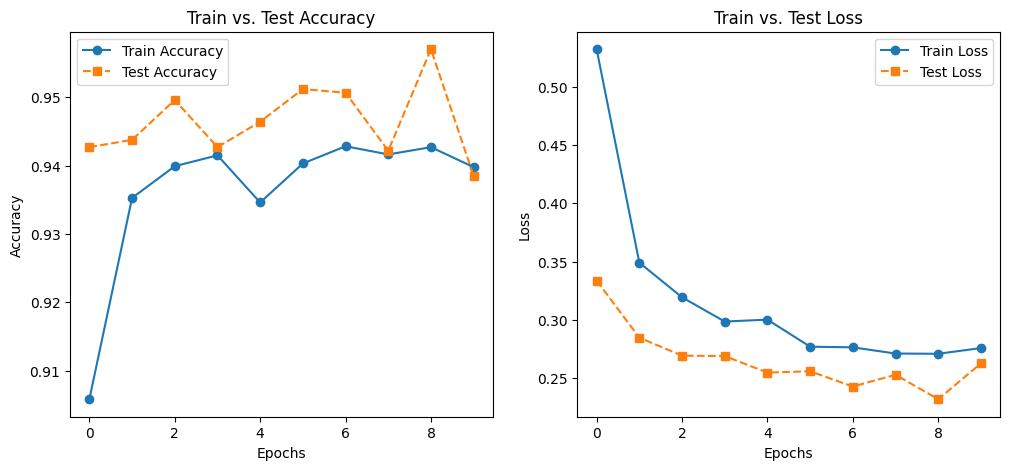

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

# ✅ 1. Load Data (Assuming in Google Drive)
from google.colab import drive
drive.mount('/content/drive')

train_path = "/content/drive/MyDrive/Colab Notebooks/cataract_features.csv"
test_path = "/content/drive/MyDrive/Colab Notebooks/cataract_test_features.csv"
train_df = pd.read_csv(train_path)  # Load train data
test_df = pd.read_csv(test_path)
# Read CSV files
train_df['label'] = train_df['label'].map({'cataract': 1, 'normal': 0})
test_df['label'] = test_df['label'].map({'cataract': 1, 'normal': 0})
'''
# ✅ 2. Prepare Data
X_train = train_df.drop(columns=["label"]).values  # Drop label column, keep features
y_train = train_df["label"].astype(int).values  # Convert labels to integers

X_test = test_df.drop(columns=["label"]).values
# ✅ Convert label column to integers (if categorical)
y_test = test_df["label"].astype(int).values'''

X_train, y_train = train_df.iloc[:, :-1].values, train_df.iloc[:, -1].values
X_test, y_test = test_df.iloc[:, :-1].values, test_df.iloc[:, -1].values
# Normalize Data
X_train = X_train / np.max(X_train)
X_test = X_test / np.max(X_test)

# ✅ 3. Define MLP Model
model = Sequential([
    Dense(64, activation="relu", kernel_regularizer=l2(0.005), input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(32, activation="relu", kernel_regularizer=l2(0.005)),
    Dropout(0.3),
    Dense(1, activation="sigmoid")  # Binary classification
])

# ✅ Define Optimizer with Learning Rate
optimizer = Adam(learning_rate=0.0001)

# ✅ 4. Compile Model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ✅ 5. Train Model
early_stopping = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

# ✅ Train Model
history_vgg = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,   # ✅ Limit epochs to 10
    batch_size=64,  # ✅ Ensure reasonable batch size
    callbacks=[early_stopping],
    verbose=1)
# ✅ 6. Save Model for Future Use
model.save("/content/drive/MyDrive/Colab Notebooks/cataract_dataset/mlp_vgg_model.h5")

# ✅ 7. Plot Accuracy and Loss
plt.figure(figsize=(12, 5))

# 🔹 Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Test Accuracy', marker='s')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Train vs. Test Accuracy')
plt.legend()

# 🔹 Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Test Loss', marker='s)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train vs. Test Loss')
plt.legend()

plt.show()


mlp test

In [ ]:
import cv2
import numpy as np
import pandas as pd
import joblib
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as preprocess_vgg
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Flatten

# ---- Load Trained MLP Model ----
mlp_model_path = "/content/drive/MyDrive/Colab Notebooks/cataract_dataset/mlp_vgg_model.h5"  # Update path
mlp_model = load_model(mlp_model_path)

# ---- Load VGG16 Feature Extractor (With Flatten Layer) ----
base_model = VGG16(weights="imagenet", include_top=False)
flatten_layer = Flatten()(base_model.output)  # Flatten extracted features
vgg = Model(inputs=base_model.input, outputs=flatten_layer)  # New model with flatten output

# ---- Function to Process Image and Extract Features ----
def extract_features(image_path):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (224, 224))  # Resize to model input size
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
    img = np.expand_dims(img, axis=0)  # Add batch dimension
    img = preprocess_vgg(img)  # Preprocess for VGG16

    features = vgg.predict(img)  # Extract features
    return features  # Now returns flattened 25,088 features

# ---- Input Image Path ----
image_path = "/content/drive/MyDrive/Colab Notebooks/cataract_dataset/test/cataract/0_left_0_8492.png"
features = extract_features(image_path)

# ---- Make Prediction ----
prediction = mlp_model.predict(features)[0][0]  # Get probability

# ---- Print Result ----
if prediction >= 0.5:
    print("Prediction: Cataract Detected")
else:
    print("Prediction: Normal Eye")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 798ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Prediction: Cataract Detected


vgg+mlpevaluation

In [ ]:
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ---- Load test features from CSV ----
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/cataract_test_features.csv")

# ---- Load trained MLP model correctly ----
mlp_model = load_model("/content/drive/MyDrive/Colab Notebooks/cataract_dataset/mlp_vgg_model.h5")

# ---- Convert labels to binary format ----
df_test['label'] = df_test['label'].map({'cataract': 1, 'normal': 0})

# ---- Split features and labels ----
X_test = df_test.iloc[:, :-1].values  # Features
y_test = df_test.iloc[:, -1].values   # Labels

# ---- Predict test set ----
y_pred = mlp_model.predict(X_test)

# ---- Convert probability predictions to binary (0 or 1) ----
y_pred = (y_pred >= 0.5).astype(int)  # Threshold at 0.5

# ---- Evaluate performance ----
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 Test Accuracy: {accuracy * 100:.2f}%")

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Normal", "Cataract"]))

print("\n🔹 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
🎯 Test Accuracy: 94.43%

📊 Classification Report:
              precision    recall  f1-score   support

      Normal       0.92      0.98      0.95       945
    Cataract       0.98      0.91      0.94       940

    accuracy                           0.94      1885
   macro avg       0.95      0.94      0.94      1885
weighted avg       0.95      0.94      0.94      1885


🔹 Confusion Matrix:
[[926  19]
 [ 86 854]]


59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

📈 ROC AUC Score: 0.9527


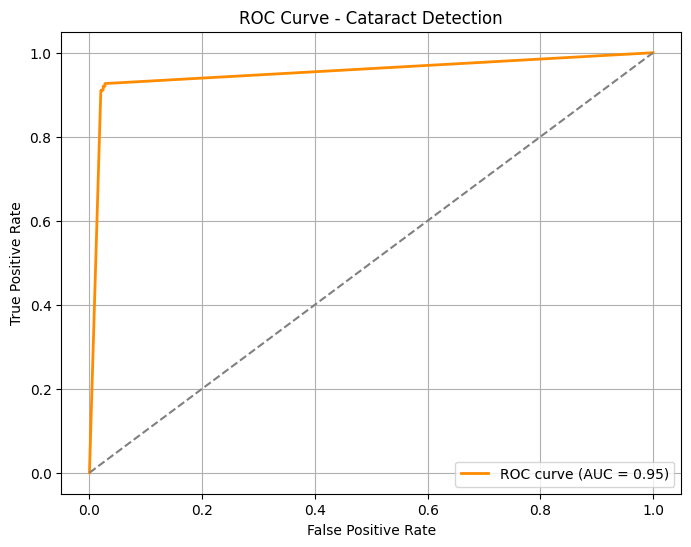

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
from tensorflow.keras.models import load_model

# ---- Load test data ----
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/cataract_test_features.csv")
mlp_model = load_model("/content/drive/MyDrive/Colab Notebooks/cataract_dataset/mlp_vgg_model.h5")

# ---- Convert string labels if needed ----
if df_test['label'].dtype == object:
    df_test['label'] = df_test['label'].map({'cataract': 1, 'normal': 0})

# ---- Separate features and labels ----
X_test = df_test.iloc[:, :-1].values
y_test = df_test.iloc[:, -1].values

# ---- Predict probabilities ----
y_pred_proba = mlp_model.predict(X_test)

# ---- Convert probabilities to binary predictions ----
y_pred = (y_pred_proba >= 0.5).astype(int).flatten()

# ---- ROC Curve and AUC ----
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n📈 ROC AUC Score: {auc:.4f}")

# ---- Plot ROC Curve ----
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Cataract Detection")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


FRONTEND


In [ ]:
!pip install gradio
import gradio as gr
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Flatten
from tensorflow.keras.models import Model

# ---- Load Trained MLP Model ----
mlp_model = load_model("/content/drive/MyDrive/Colab Notebooks/cataract_dataset/mlp_vgg_model.h5")

# ---- Load VGG16 Feature Extractor (Flatten Output to 25088 Features) ----
vgg_base = VGG16(weights="imagenet", include_top=False)  # NO "pooling"
vgg = Model(inputs=vgg_base.input, outputs=Flatten()(vgg_base.output))  # Ensures output is 25088

# ---- Function to Process Image and Extract Features ----
def extract_features(image):
    img = cv2.resize(image, (224, 224))  # Resize to VGG16 input size
    img = np.expand_dims(img, axis=0)  # Add batch dimension
    img = preprocess_input(img)  # Apply VGG16 preprocessing

    features = vgg.predict(img)  # Extract features
    print("Feature Shape:", features.shape)  # Debug print (should be (1, 25088))

    return features

# ---- Function for Prediction ----
def predict_cataract(image):
    try:
        # Convert PIL image to OpenCV format
        image = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

        # Extract features
        features = extract_features(image)

        # Ensure correct shape for MLP
        print("Input Shape for MLP:", features.shape)  # Debug print

        # Predict using MLP model
        prediction = mlp_model.predict(features)
        print("Raw Prediction:", prediction)  # Debug print

        # Check if output needs argmax
        if prediction.shape[-1] > 1:
            prediction = np.argmax(prediction)  # For multi-class classification
        else:
            prediction = prediction[0][0]  # For binary classification

        # Threshold to classify as Normal (0) or Cataract (1)
        return "🩺Cataract Detected" if prediction >= 0.5 else "👀Normal Eye"

    except Exception as e:
        return f"Error: {e}"  # Print error message for debugging

# ---- Gradio Interface ----
interface = gr.Interface(
    fn=predict_cataract,
    inputs=gr.Image(type="pil"),
    outputs="text",
    title="Cataract Detection MLP",
    description="Upload an eye image to detect cataract using a VGG16 feature extractor and MLP model."
)

# ---- Launch App ----
interface.launch()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.2/322.2 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 7.1 MB/s eta 0:00:00


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3be88fc4c2119b2fe6.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


**RESNET+**

In [ ]:
nextpage